In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('NFLX.csv')

In [3]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   object 
 1   Open       1009 non-null   float64
 2   High       1009 non-null   float64
 3   Low        1009 non-null   float64
 4   Close      1009 non-null   float64
 5   Adj Close  1009 non-null   float64
 6   Volume     1009 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 55.3+ KB


In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,1009,1009,2018-02-05,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Open,1009.0,NaN,NaN,NaN,419.059673,108.537532,233.919998,331.48999,377.769989,509.130005,692.349976
High,1009.0,NaN,NaN,NaN,425.320703,109.26296,250.649994,336.299988,383.01001,515.630005,700.98999
Low,1009.0,NaN,NaN,NaN,412.374044,107.555867,231.229996,326.0,370.880005,502.529999,686.090027
Close,1009.0,NaN,NaN,NaN,419.000733,108.289999,233.880005,331.619995,378.670013,509.079987,691.690002
Adj Close,1009.0,NaN,NaN,NaN,419.000733,108.289999,233.880005,331.619995,378.670013,509.079987,691.690002
Volume,1009.0,NaN,NaN,NaN,7570685.034688,5465535.22569,1144000.0,4091900.0,5934500.0,9322400.0,58904300.0


In [6]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

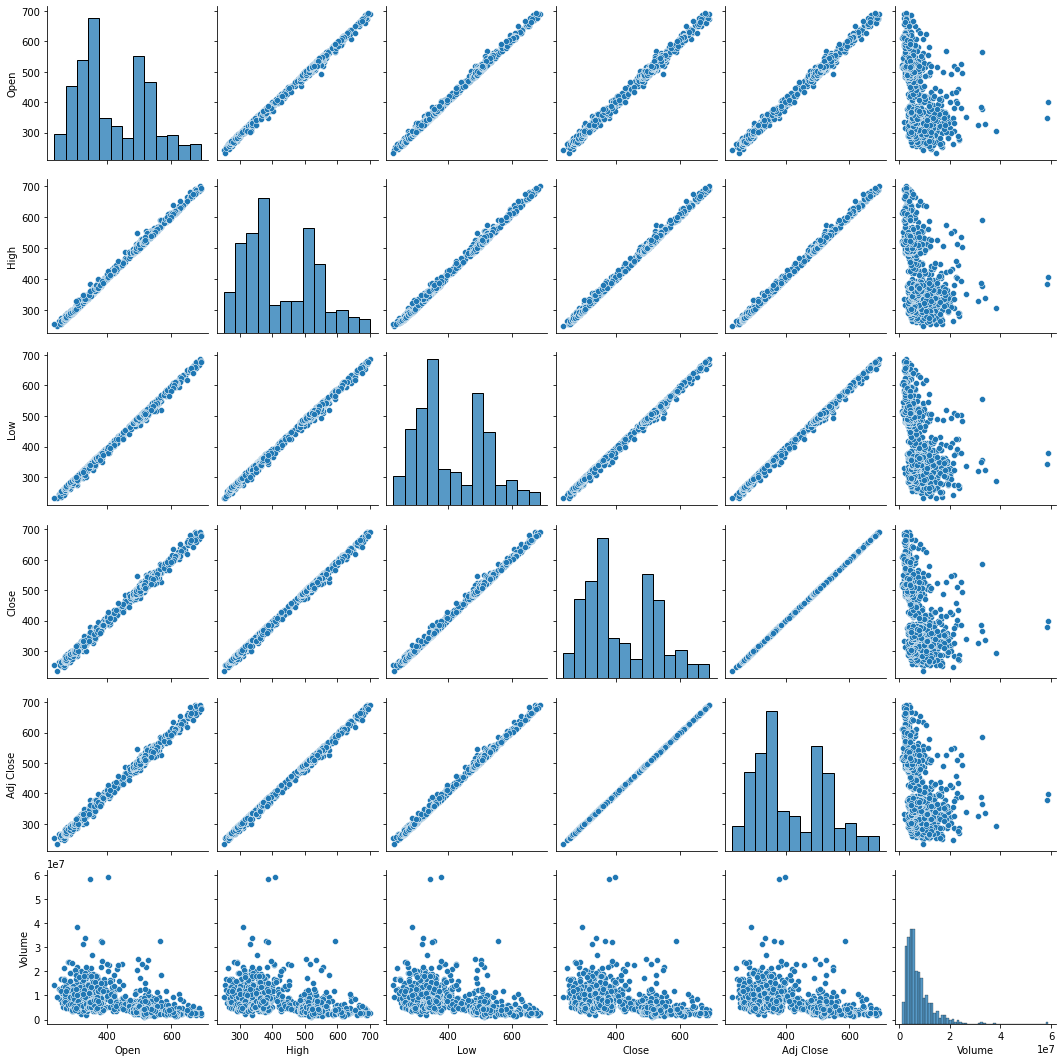

In [7]:
sns.pairplot(df)

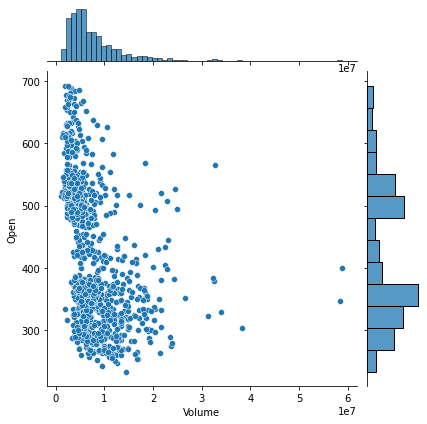

In [8]:
sns.jointplot(data=df,x='Volume',y='Open')

<AxesSubplot:xlabel='Open', ylabel='Count'>

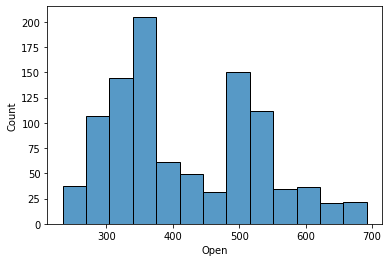

In [9]:
sns.histplot(data=df,x='Open')

In [10]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [11]:
X = df[['Open', 'High', 'Low','Volume']]
y = df[['Close']]

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.333)

In [13]:
linear = LinearRegression()
linear.fit(X_train,y_train)

LinearRegression()

In [14]:
linear.score(X_test,y_test)

0.9988902200284289

In [15]:
decision = DecisionTreeRegressor()
decision.fit(X_train,y_train)

DecisionTreeRegressor()

In [16]:
decision.score(X_test,y_test)

0.9964995758863535

In [17]:
random = RandomForestRegressor()
random.fit(X_train,y_train)

C:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1351: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor()

In [18]:
random.score(X_test,y_test)

0.9978321641214135

In [19]:
xgb = XGBRegressor()
xgb.fit(X_train,y_train)

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=0, gpu_id=-1,
             grow_policy='depthwise', importance_type=None,
             interaction_constraints='', learning_rate=0.300000012, max_bin=256,
             max_cat_threshold=64, max_cat_to_onehot=4, max_delta_step=0,
             max_depth=6, max_leaves=0, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, ...)

In [20]:
xgb.score(X_test,y_test)

0.9969613745527598